In [1]:
import streamobs as so
import numpy as np
import matplotlib.pyplot as plt
import streamgoggles.matched_filter 

In [2]:
survey  = so.surveys.Survey.load("des", release="yr6")

Loading survey data for 'des_yr6'...
  Loading config from: des_yr6.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/des_yr6

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ✓ Success for i-band magnitude limit
  ✓ Success for r-band magnitude limit
  ✓ Success for z-band magnitude limit

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: des_yr6_stellar_efficiency_cutg.csv
    ✓ Success
  Loading Detection efficiency function...
    File: des_yr6_stellar_efficiency_cutg.csv
    ✓ Success
  Loading Classification efficiency function...
    File: des_yr6_stellar_efficiency_cutg.csv
    ✓ Success
  Loading Galaxy misclassification efficiency...
    File: de

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/surveys.py:1291: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  survey.maglim_maps[band] = hp.read_map(full_path, verbose=False)


23.375185 26.03978
g-band percentiles: 16th=24.88, 84th=25.13
r-band percentiles: 16th=24.72, 84th=24.95


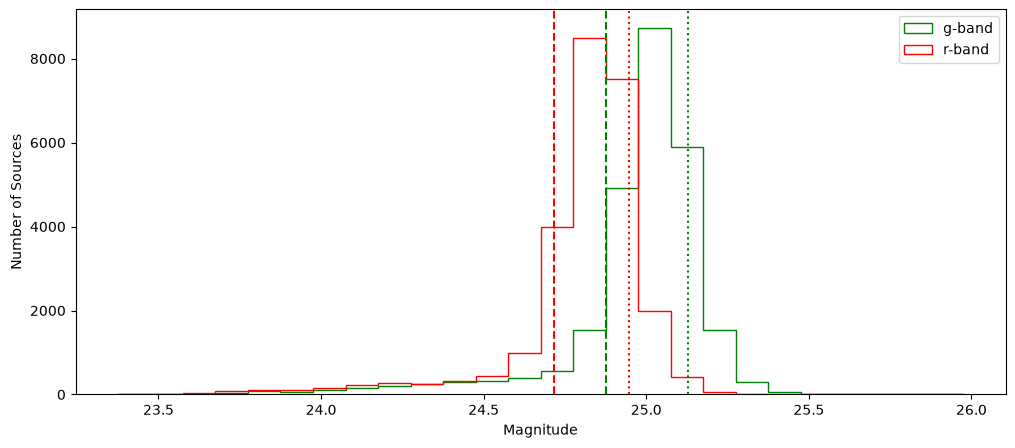

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
maglim_g = survey.maglim_maps['g']
maglim_r = survey.maglim_maps['r']
maglim_g = maglim_g[maglim_g > 0]
maglim_r = maglim_r[maglim_r > 0]
min_ax = np.nanmin([np.nanmin(maglim_g), np.nanmin(maglim_r)])
max_ax = np.nanmax([np.nanmax(maglim_g), np.nanmax(maglim_r)])
print(min_ax, max_ax)
bins = np.arange(min_ax, max_ax, 0.1)
percentile_min, percentile_max = 16, 84
percentiles_g = np.nanpercentile(maglim_g, [percentile_min, percentile_max])
percentiles_r = np.nanpercentile(maglim_r, [percentile_min, percentile_max])
ax.hist(survey.maglim_maps['g'],bins=bins, label='g-band', histtype='step', color='g')
ax.hist(survey.maglim_maps['r'],bins=bins, label='r-band', histtype='step', color='r')
ax.axvline(percentiles_g[0], color='g', ls='--',)
ax.axvline(percentiles_r[0], color='r', ls='--', )
ax.axvline(percentiles_g[1], color='g', ls=':', )
ax.axvline(percentiles_r[1], color='r', ls=':', )
ax.set_xlabel('Magnitude')
ax.set_ylabel('Number of Sources')
ax.legend()
print(f"g-band percentiles: 16th={percentiles_g[0]:.2f}, 84th={percentiles_g[1]:.2f}")
print(f"r-band percentiles: 16th={percentiles_r[0]:.2f}, 84th={percentiles_r[1]:.2f}")

In [4]:
maglim = np.min([percentiles_g[0], percentiles_r[0]])
mag_test = np.linspace(16, maglim + 2, 100)

err_streamsim = survey.get_photo_error(
    "g", magnitude=mag_test, maglim=maglim, 
    kind= "sample",
    #kind = "catalog",
)

result = streamgoggles.matched_filter.fit_error_model(mag_test, err_streamsim)
print("Fitted parameters:", result)

Fitted parameters: {'baseline_error': 0.019579371768489562, 'exp_pivot': 28.15402813670924, 'exp_scale': 1.553901771037452}


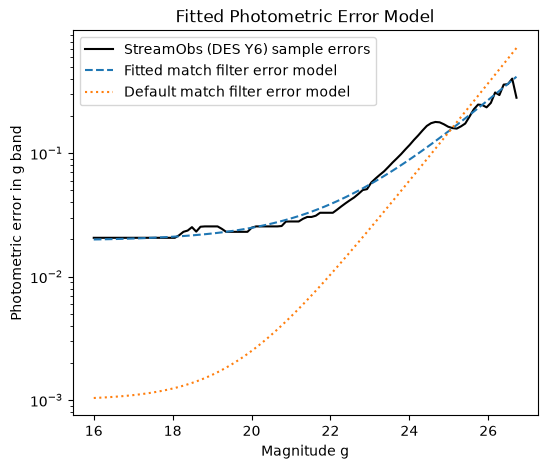

In [5]:


err_results = streamgoggles.matched_filter.error_model(
    mag_test, result["baseline_error"], result["exp_pivot"], result["exp_scale"]
)
err_defaults = streamgoggles.matched_filter.error_model(mag_test)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(mag_test, err_streamsim, label="StreamObs (DES Y6) sample errors", color="k")
ax.plot(mag_test, err_results, label="Fitted match filter error model", linestyle="--")
ax.plot(mag_test, err_defaults, label="Default match filter error model", linestyle=":")
ax.set_yscale("log")
ax.set_xlabel("Magnitude g")
ax.set_ylabel("Photometric error in g band")
ax.set_title("Fitted Photometric Error Model")
ax.legend()
plt.show()



**Fit range.** The fit above runs to two magnitudes past the depth (26.7).
Past about 24.7 the DES Y6 scatter flattens and dips near the detection limit,
which a rising exponential cannot follow, and chasing it pulls the model 24%
*below* the true scatter at g 23.5-24.5 — exactly where a distant stream's
stars are. The adopted model, `DES_YR6_ERROR_MODEL`, is fitted over g 16-24.5
instead, the range the filter selects in (`fit_survey_error_model()`'s
default), and follows the scatter to 5% rms there. The cells below use it;
docs/source/experiments/matched_filter_errors.md has the comparison.

## The filters these error models give

Three filters around the same 13 Gyr, Z = 0.0002 isochrone, differing only in
the photometric errors that widen it:

- **current**: no error model given, so streamobs uses its default -- fitted on
  **LSST DC2**, not DES -- at streamobs's default 2 sigma on each side;
- **DES Y6, 2 sigma**: `DES_YR6_ERROR_MODEL`, same multiplier;
- **DES Y6, 1 sigma**: the same errors, spanned once on each side.

The grey points are a simulated DES stream at each distance -- the stars the
filter is supposed to keep -- produced by the same injection pipeline as the
training data, inside the 16-24.5 clip the models use.

✓ Using cached survey data for 'des_yr6'


/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


✓ Using cached survey data for 'des_yr6'


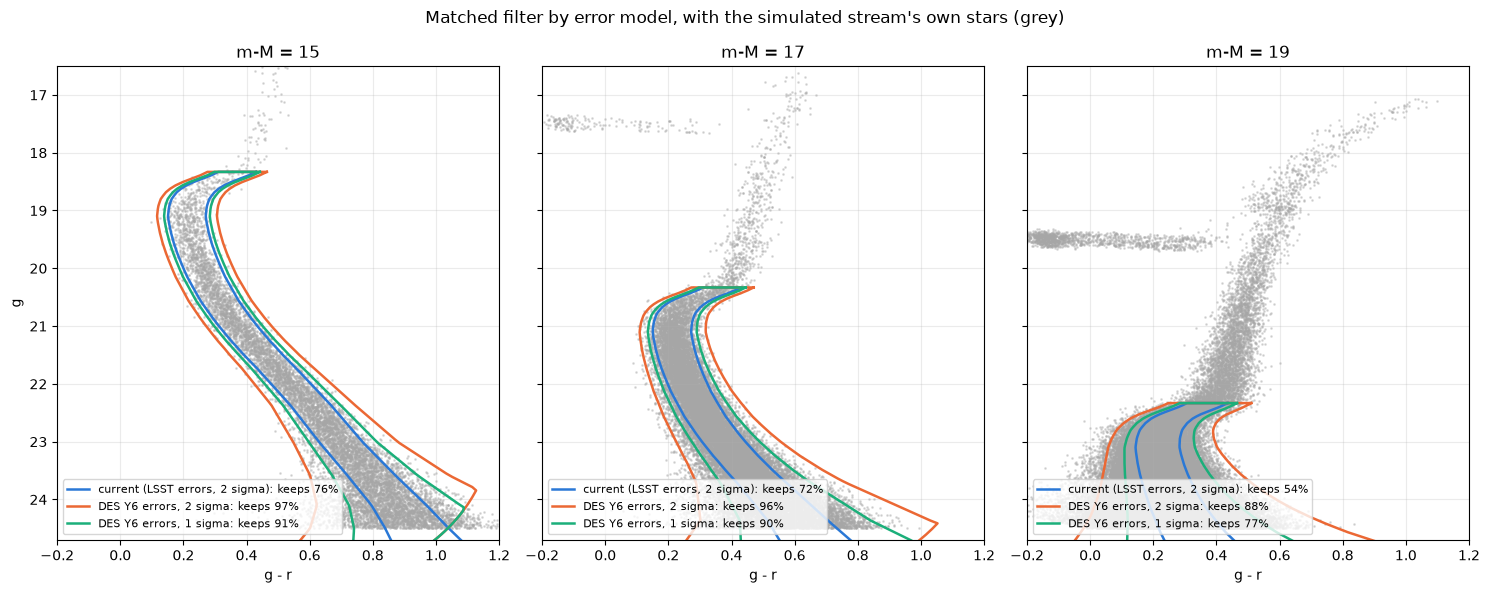

In [6]:
import importlib.util
import pandas as pd
from streamgoggles.matched_filter import DES_YR6_ERROR_MODEL, build_matched_filters

spec = importlib.util.spec_from_file_location("sp_run", "../scripts/experiments/stream_parameters/run.py")
run = importlib.util.module_from_spec(spec); spec.loader.exec_module(run)
_, injector = run.build_sky(run.BACKGROUND_SEED)   # about a minute

isochrone = {"type": "isochrone", "reference_isochrone": {"age": 13.0, "z": 0.0002}}
filters = build_matched_filters(
    {
        "current (LSST errors, 2 sigma)": isochrone,
        "DES Y6 errors, 2 sigma": {**isochrone, "error_model": DES_YR6_ERROR_MODEL},
        "DES Y6 errors, 1 sigma": {**isochrone, "error_model": DES_YR6_ERROR_MODEL, "error_multiplier": [1.0, 1.0]},
    },
    namespace="des_yr6",
)
colours = ["#2a78d6", "#eb6834", "#1baf7a"]

def stream_stars(dm, n_realizations=3):
    """Observed stars of a bright simulated stream at this distance, inside the clip."""
    params = {"morphology": "uniform", "richness": 32.0, "width": 0.5, "length": 10.0,
              "distance_modulus": dm, "age": 13.0, "z": 0.0002}
    stars = pd.concat([injector._realize_and_inject(params, np.random.default_rng(k))[0]
                       for k in range(n_realizations)])
    g, r = stars["des_yr6_g_obs"], stars["des_yr6_r_obs"]
    return stars[g.between(16, 24.5) & r.between(16, 24.5)]

distances = [15.0, 17.0, 19.0]
simulated = {dm: stream_stars(dm) for dm in distances}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, dm in zip(axes, distances):
    stars = simulated[dm]
    ax.scatter(stars["des_yr6_g_obs"] - stars["des_yr6_r_obs"], stars["des_yr6_g_obs"],
               s=1, color="0.65", alpha=0.35, rasterized=True)
    for (name, f), colour in zip(filters.items(), colours):
        polygon = f._polygon(["g", "r"], dm)
        kept = f.select(stars, ["g", "r"], dm).mean()
        closed = np.vstack([polygon, polygon[:1]])
        ax.plot(closed[:, 0], closed[:, 1], color=colour, lw=1.8,
                label=f"{name}: keeps {100 * kept:.0f}%")
    ax.set_title(f"m-M = {dm:g}")
    ax.set_xlabel("g - r")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(24.7, 16.5)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("g")
fig.suptitle("Matched filter by error model, with the simulated stream's own stars (grey)")
plt.tight_layout()
plt.show()

## Is wider better? Stream stars against background stars

Keeping more of the stream is only useful if the filter does not let in
proportionally more background. For counting statistics the figure of merit
is stream stars kept over the square root of background stars kept, measured
here on a patch of the real, masked DES Y6 background and shown relative to
the current filter.

In [7]:
background = pd.read_parquet("~/Documents/data/DES_yr6/des_yr6_background.parquet")
patch = background[background.ra.between(10, 40) & background.dec.between(-40, -30)]
print(f"real background patch: {len(patch):,} stars\n")
print(f"{'m-M':>4}  {'filter':<32}{'stream kept':>12}{'S/sqrt(B)':>11}")
for dm in distances:
    reference = None
    for name, f in filters.items():
        kept = f.select(simulated[dm], ["g", "r"], dm).mean()
        background_kept = f.select(patch, ["g", "r"], dm).sum()
        merit = kept / np.sqrt(background_kept)
        reference = reference or merit
        print(f"{dm:4g}  {name:<32}{100 * kept:11.1f}%{merit / reference:10.2f}x")
    print()

real background patch: 991,804 stars

 m-M  filter                           stream kept  S/sqrt(B)


  15  current (LSST errors, 2 sigma)         75.9%      1.00x


  15  DES Y6 errors, 2 sigma                 96.8%      0.86x


  15  DES Y6 errors, 1 sigma                 91.4%      0.98x



  17  current (LSST errors, 2 sigma)         71.9%      1.00x


  17  DES Y6 errors, 2 sigma                 96.1%      0.82x


  17  DES Y6 errors, 1 sigma                 90.0%      0.96x



  19  current (LSST errors, 2 sigma)         53.6%      1.00x


  19  DES Y6 errors, 2 sigma                 87.5%      0.92x


  19  DES Y6 errors, 1 sigma                 76.9%      1.04x

